# Projekt Zespołowy 2 — Zespół 10, "Sieci"

## Początkowa konfiguracja

W przypadku uruchomienia na Google Colab, dokonywane jest montowanie dysku i instalacja potrzebnych bibliotek.

In [ ]:
try:
    from google.colab import drive  # type: ignore
    import sys, os

    drive.mount("/content/drive")
    Project_Path = "drive/MyDrive/PZSP2-Z10/"
    sys.path.append(Project_Path + "src/")
    os.system(f"uv pip install -r {Project_Path}pyproject.toml")
except:
    Project_Path = "./"

# Benchmark AMPL

### Ścieżka do plików AMPL

Własne pliki należy umieścić w folderze `src/AMPL/` bądź wpisać ścieżkę do nich poniżej:

In [ ]:
AMPL_PATH = Project_Path + "src/AMPL/"
AMPL_MODEL = "full-mesh.mod"
AMPL_DATA = "full-mesh.dat"

# dane potrzebne w eksperymentach z sieciami rzeczywistymi
# w nich pliki .dat są generowane na bieżąco
transponder_names = ["A", "B", "C", "D", "E"]
transponder_capacities = {"A": 40, "B": 100, "C": 200, "D": 400, "E": 800}
transponder_costs = {"A": 1, "B": 3, "C": 5, "D": 9, "E": 11}

### Import bibliotek

In [ ]:
from pathlib import PurePath
from amplpy import ampl_notebook  # type: ignore
import networkx as nx
import matplotlib.pyplot as plt
import time

# generator plików .dat dla modeli AMPL na podstawie opisów sieci z serwisu SNDlib
from net_opt.utils.ampl_data_creator import AMPL_Data_Creator

### Konfiguracja solvera

In [ ]:
# konieczne może być dostarczenie własnej licencji AMPL
ampl = ampl_notebook(license_uuid="default")
ampl.read(str(PurePath(AMPL_PATH + AMPL_MODEL)))
ampl.read_data(str(PurePath(AMPL_PATH + AMPL_DATA)))
N = ampl.get_parameter("n").value()
ampl.option["solver"] = "cplex"

### Funkcje pomocniczne do wywoływania modelu AMP - rozwiązanie zadania oraz wizualizacja rozwiązania

In [ ]:
def ampl_solve_fullmesh_task(N):
  ampl.reset()

  # aby skorzystać z modelu AMPL należy go załadować na czysto za każdym razem
  ampl.read(str(PurePath(AMPL_PATH+AMPL_MODEL)))
  ampl.read_data(str(PurePath(AMPL_PATH+AMPL_DATA)))

  nodes = ampl.get_parameter("n")
  nodes.set(N)

  start = time.perf_counter()
  ampl.solve()
  AMPL_time = time.perf_counter() - start

  assert ampl.solve_result == "solved"
  print(f"AMPL Solved in {AMPL_time:f}s")

  print(f"Total cost: {ampl.get_objective("total_cost").value()}")
  flow = ampl.get_variable("usage").get_values().to_pandas()
  print(f"Flow matrix:\n{flow}")
  encryption = ampl.get_variable("encrypted").get_values().to_pandas()
  print(f"Encrypted edges:\n{encryption}")
  bandwidth = ampl.get_data("{(i,j) in EDGES} sum {(k,l) in CONNECTIONS} (usage[i,j,k,l]+usage[j,i,k,l])").to_pandas()
  bandwidth.rename(columns={bandwidth.columns[0]: "bandwidth"}, inplace=True)
  print(f"Bandwidth usage:\n{bandwidth}")

  G = nx.Graph()
  G.add_nodes_from(range(1,N+1))
  G.add_weighted_edges_from([(i,j,bandwidth.at[(i,j),"bandwidth"]) for i in range(1,N+1) for j in range(1,N+1) if i<j])
  nx.set_edge_attributes(G, encryption.to_dict()['encrypted.val'], "encrypted")
  print(list(G.edges))
  print(nx.get_edge_attributes(G, "encrypted"))
  colors = [edge[2] for edge in G.edges.data("encrypted")]
  pos = nx.shell_layout(G)
  nx.draw(G, pos=pos, with_labels=True, font_weight='bold', edge_color=colors)
  nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=nx.get_edge_attributes(G, "weight"))
  plt.show()

In [ ]:
def ampl_solve_other_task(nodes):
  ampl.reset()

  # aby skorzystać z modelu AMPL należy go załadować na czysto za każdym razem
  ampl.read(str(PurePath(AMPL_PATH+AMPL_MODEL)))
  ampl.read_data(str(PurePath(AMPL_PATH+AMPL_DATA)))

  N = len(nodes)

  start = time.perf_counter()
  ampl.solve()
  AMPL_time = time.perf_counter() - start

  assert ampl.solve_result == "solved"
  print(f"AMPL Solved in {AMPL_time:f}s")

  print(f"Total cost: {ampl.get_objective("total_cost").value()}")
  flow = ampl.get_variable("usage").get_values().to_pandas()
  print(f"Flow matrix:\n{flow}")
  encryption = ampl.get_variable("encrypted").get_values().to_pandas()
  print(f"Encrypted edges:\n{encryption}")
  bandwidth = ampl.get_data("{(i,j) in EDGES} sum {(k,l) in CONNECTIONS} (usage[i,j,k,l]+usage[j,i,k,l])").to_pandas()
  bandwidth.rename(columns={bandwidth.columns[0]: "bandwidth"}, inplace=True)
  print(f"Bandwidth usage:\n{bandwidth}")

  # visualisation currently unavailable for non-fullmesh nets
  # G = nx.Graph()
  # G.add_nodes_from(range(1,N+1))
  # G.add_weighted_edges_from([(i,j,bandwidth.at[(i,j),"bandwidth"]) for i in range(1,N+1) for j in range(1,N+1) if i<j])
  # nx.set_edge_attributes(G, encryption.to_dict()['encrypted.val'], "encrypted")
  # print(list(G.edges))
  # print(nx.get_edge_attributes(G, "encrypted"))
  # colors = [edge[2] for edge in G.edges.data("encrypted")]
  # pos = nx.shell_layout(G)
  # nx.draw(G, pos=pos, with_labels=True, font_weight='bold', edge_color=colors)
  # nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=nx.get_edge_attributes(G, "weight"))
  # plt.show()

# Algorytm Ewolucyjny

### Import bibliotek oraz przygotowanie podstawowych danych wejściowych

In [ ]:
# net_opt jest modułem w języku python zawierającym wszystkie potrzebne
# elementy do wykorzystywania algorytmu ewolucyjnego w tym narzędziu
from net_opt.core.constraints.bandwidth_limit import BandwidthLimit
from net_opt.core.constraints.demand import Demand
from net_opt.core.constraints.dependent_demand import DependentDemand
from net_opt.core.constraints.path_bandwidth_io_match import PathBandwidthIOMatch
from net_opt.core.constraints.path_edge_bandwidth_kirchhoff_match import PathEdgeBandwidthKirchhoffMatch
from net_opt.core.constraints.path_transponder_bandwidth_weak import PathTransponderBandwidthWeak
from net_opt.core.ea import EA, FastEA
from net_opt.core.mutations.base_mutation import Mutation
from net_opt.core.mutations.gene_mutation import GeneMutation
from net_opt.core.mutations.uniform_crossover import UniformCrossover
from net_opt.core.selections.tournament_selection import TournamentSelection
from net_opt.core.termination_conditions.base_termination_condition import TerminationCondition
from net_opt.core.termination_conditions.time_limit import TimeLimit
from net_opt.core.termination_conditions.max_iterations import MaxIterations
from net_opt.utils.visualisation import visualize_input_data, visualize_population_individual
from net_opt.utils.distributions import get_opt_init_dist

import torch
from torch.distributions import Categorical
import pprint
import jaxtyping

# parser do formatowania danych z serwisu sndlib na potrzeby reprezentacji sieci
from net_opt.utils.sndlib_parser import SNDlib_Parser

pp = pprint.PrettyPrinter(indent=4)

### CUDA

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Running on {device} ---")
torch.set_default_device(device)

### Podstawowe dane wejściowe

In [ ]:
# Opcja przydatna przy debugowaniu, natomiast spowalniajaca obliczenia
jaxtyping.config.update("jaxtyping_disable", True)

# testowa liczba węzłów, dla tej i paru większych wartości zaprezentujemy
# działanie narzędzia w kilku przykładowych eksperymentach
N=5
encrypted_bandwidth = 30
regular_bandwidth = 96

# zdefiniowanie transpenderów, razem z pojemnością rośnie cena
mock_transponder_capacities = torch.tensor([40.0, 100.0, 200.0, 400.0, 800.0])
mock_transponder_costs = torch.tensor([1.0, 3.0, 5.0, 9.0, 11.0])
T = mock_transponder_capacities.shape[0]

path_dist, trans_dist = get_opt_init_dist(N, T, encrypted_bandwidth, regular_bandwidth)

# dane konfiguracyjne do samego algorytmu, siły mutacji, rozmiar populacji, ilość iteracji itp
mutation_config: list[Mutation] =[
    GeneMutation(
        path_edge_bandwidth_usage_mut_proba=0.5,
        path_transponder_assignment_mut_proba=0.5
    ),
    UniformCrossover(
        path_edge_bandwidth_usage_cross_proba=0.5,
        path_transponder_assignment_cross_proba=0.5
    )
]
selection_config = TournamentSelection(k=3)
termination_config : list[TerminationCondition] = [
    MaxIterations(iterations=10000),
]

ea_config = EA(
    show_vizualisation_every_n_iter=1000,
    population_size=1000,
    elite_size=50,
    path_edge_bandwidth_usage_init_distribution=path_dist,
    path_transponder_assignment_init_distribution=trans_dist,
    constraints=[
        PathBandwidthIOMatch(),
        PathEdgeBandwidthKirchhoffMatch(),
        PathTransponderBandwidthWeak(),
        Demand(),
        BandwidthLimit(),
        ],
    termination_conditions=termination_config,
    selection_method=selection_config,
    mutation_methods=mutation_config,
    global_constraint_weight=10000,
	device=device
)

### Funkcje pomocnicze

In [ ]:
from typing import List, Tuple

def ea_summarize_run():
  print("\n--- EA Run Finished ---")
  print(f"Total iterations: {ea_instance._iteration_n}")
  visualize_population_individual(ea_instance._population, ea_instance._transponder_capacities)
  dict_constraint_name_scores ={
  ea_instance.constraints[i].readable_name: ea_instance._lowest_penalty_constraint_scores[i]
  for i in range(len(ea_instance._constraint_scores))
  }
  print("-"*40)
  print(f"it: {ea_instance._iteration_n}")
  print(f"lowest_penalty: {ea_instance._lowest_penalty}")
  print("lowest_penalty_constraint_scores:")
  pp.pprint(dict_constraint_name_scores)
  print(f"lowest_transponder_cost: {ea_instance._lowest_transponder_cost}")


def set_connections(N, connection_list: List[Tuple[int, int]]):
  neigh_matrix = torch.zeros((N, N), dtype=torch.bool)
  for connection in connection_list:
    a, b = connection
    neigh_matrix[a-1][b-1] = neigh_matrix[b-1][a-1] = True
  return neigh_matrix

# Przykładowe eksperymenty

## Fullmesh z 5 węzłami

### Rozwiązanie modelem AMPL

In [ ]:
# podstawowy model do rozwiązywania zadań z sieciami typu full-mesh
AMPL_MODEL = "full-mesh.mod"
AMPL_DATA = "full-mesh.dat"

In [ ]:
N = 5 # liczba węzłów w sieci fullmesh
ampl_solve_fullmesh_task(N)

### Rozwiązanie algorytmem ewolucyjnym

In [ ]:
N = 5 # liczba węzłów w sieci fullmesh
mock_neigh_matrix = ~torch.eye(N, dtype=torch.bool) # macierz sąsiedztwa, tu zachodzi zdefiniowanie struktury sieci
mock_demand = torch.triu(torch.full((N, N), 44000, dtype=torch.float), diagonal=1) # zapotrzebowanie w sieci

### Wizualizacja danych wejściowych

In [ ]:
visualize_input_data(
    mock_neigh_matrix,
    mock_demand,
    mock_transponder_costs,
    mock_transponder_capacities
)

### Wykonanie eksperymentu

In [ ]:
ea_instance = ea_config
ea_instance.run(
    encrypted_bandwidth = encrypted_bandwidth,
    regular_bandwidth = regular_bandwidth,
    neigh_matrix=mock_neigh_matrix,
    demand=mock_demand,
    transponder_costs=mock_transponder_costs,
    transponder_capacities=mock_transponder_capacities
)


ea_summarize_run()

### Rozwiązanie zadania

In [ ]:
start = time.perf_counter()
ampl.solve()
AMPL_time = time.perf_counter() - start
assert ampl.solve_result == "solved"
print(f"AMPL Solved in {AMPL_time:f}s")

### Wizualizacja rozwiązania

In [ ]:
print(f"Total cost: {ampl.get_objective("total_cost").value()}")
flow = ampl.get_variable("usage").get_values().to_pandas()
print(f"Flow matrix:\n{flow}")
encryption = ampl.get_variable("encrypted").get_values().to_pandas()
print(f"Encrypted edges:\n{encryption}")
bandwidth = ampl.get_data(
    "{(i,j) in EDGES} sum {(k,l) in CONNECTIONS} (usage[i,j,k,l]+usage[j,i,k,l])"
).to_pandas()
bandwidth.rename(columns={bandwidth.columns[0]: "bandwidth"}, inplace=True)
print(f"Bandwidth usage:\n{bandwidth}")

G = nx.Graph()
G.add_nodes_from(range(1, N + 1))
G.add_weighted_edges_from(
    [
        (i, j, bandwidth.at[(i, j), "bandwidth"])
        for i in range(1, N + 1)
        for j in range(1, N + 1)
        if i < j
    ]
)
nx.set_edge_attributes(G, encryption.to_dict()["encrypted.val"], "encrypted")
print(list(G.edges))
print(nx.get_edge_attributes(G, "encrypted"))
colors = [edge[2] for edge in G.edges.data("encrypted")]
pos = nx.shell_layout(G)
nx.draw(G, pos=pos, with_labels=True, font_weight="bold", edge_color=colors)
nx.draw_networkx_edge_labels(
    G, pos=pos, edge_labels=nx.get_edge_attributes(G, "weight")
)
plt.show()

## Fullmesh z 10 węzłami

### Rozwiązanie modelem AMPL

In [ ]:
# podstawowy model do rozwiązywania zadań z sieciami typu full-mesh
AMPL_Model = "full-mesh.mod"
AMPL_Data = "full-mesh.dat"

In [ ]:
N = 10 # liczba węzłów w sieci fullmesh
ampl_solve_fullmesh_task(N)

### Rozwiązanie algorytmem ewolucyjnym

In [ ]:
N = 10 # liczba węzłów w sieci fullmesh
mock_neigh_matrix = ~torch.eye(N, dtype=torch.bool) # macierz sąsiedztwa, tu zachodzi zdefiniowanie struktury sieci
mock_demand = torch.triu(torch.full((N, N), 44000, dtype=torch.float), diagonal=1)

### Wizualizacja danych wejściowych

In [ ]:
visualize_input_data(
    mock_neigh_matrix,
    mock_demand,
    mock_transponder_costs,
    mock_transponder_capacities
)

### Wykonanie eksperymentu

In [ ]:
path_dist, trans_dist = get_opt_init_dist(N, T, encrypted_bandwidth, regular_bandwidth)
ea_config.path_edge_bandwidth_usage_init_distribution = path_dist
ea_config.path_transponder_assignment_init_distribution = trans_dist
ea_instance = ea_config
ea_instance.run(
    encrypted_bandwidth = encrypted_bandwidth,
    regular_bandwidth = regular_bandwidth,
    neigh_matrix=mock_neigh_matrix,
    demand=mock_demand,
    transponder_costs=mock_transponder_costs,
    transponder_capacities=mock_transponder_capacities
)

ea_summarize_run()

## Fullmesh z 20 węzłami

### Rozwiązanie modelem AMPL

In [ ]:
# podstawowy model do rozwiązywania zadań z sieciami typu full-mesh
AMPL_MODEL = "full-mesh.mod"
AMPL_DATA= "full-mesh.dat"

In [ ]:
N = 20 # liczba węzłów w sieci fullmesh
ampl_solve_fullmesh_task(N)

### Rozwiązanie algorytmem ewolucyjnym

In [ ]:
N = 20 # liczba węzłów w sieci fullmesh
mock_neigh_matrix = ~torch.eye(N, dtype=torch.bool) # macierz sąsiedztwa, tu zachodzi zdefiniowanie struktury sieci
mock_demand = torch.triu(torch.full((N, N), 44000, dtype=torch.float), diagonal=1)

### Wizualizacja danych wejściowych

In [ ]:
visualize_input_data(
    mock_neigh_matrix,
    mock_demand,
    mock_transponder_costs,
    mock_transponder_capacities
)

### Wykonanie eksperymentu

In [ ]:
path_dist, trans_dist = get_opt_init_dist(N, T, encrypted_bandwidth, regular_bandwidth)
ea_config.path_edge_bandwidth_usage_init_distribution = path_dist
ea_config.path_transponder_assignment_init_distribution = trans_dist
ea_instance = ea_config
ea_instance.run(
    encrypted_bandwidth = encrypted_bandwidth,
    regular_bandwidth = regular_bandwidth,
    neigh_matrix=mock_neigh_matrix,
    demand=mock_demand,
    transponder_costs=mock_transponder_costs,
    transponder_capacities=mock_transponder_capacities
)


ea_summarize_run()

## Przykład sieci rzeczywistej - atlanta
wszystkie przykłady sieci rzeczywistych wykorzystywane w tych eksperymentach pochodzą ze strony https://sndlib.put.poznan.pl/home.action.

Poniżej znajduje się diagram sieci pozyskany w wcześniej wymienionej strony:
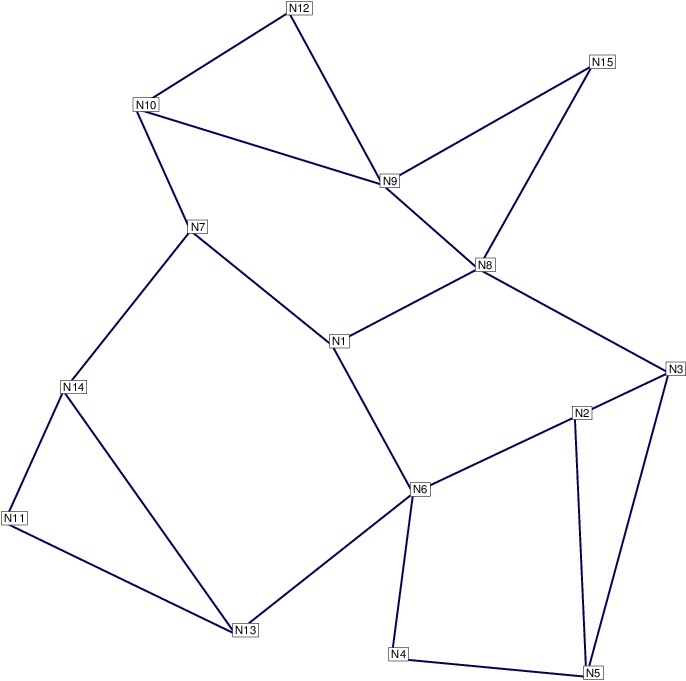

In [ ]:
SNDlib_Path = Project_Path + "src/SNDlib/"

### Rozwiązanie modelem AMPL

In [ ]:
# podstawowy model do rozwiązywania zadań z sieciami typu full-mesh
sndlib_parser = SNDlib_Parser(SNDlib_Path+"atlanta_net.txt")
nodes, node_connections = sndlib_parser.get_nodes_edges_as_ints()

ampl_data_creator = AMPL_Data_Creator()
atlanta_dat = ampl_data_creator.generate_ampl_data(encrypted_bandwidth, regular_bandwidth, nodes, transponder_names, 2500, transponder_capacities, transponder_costs, node_connections)

AMPL_MODEL = "any-net.mod"
AMPL_DATA = "atlanta_net.dat"

with open(AMPL_PATH+AMPL_DATA, "w") as f:
  f.write(atlanta_dat)

In [ ]:
ampl_solve_other_task(nodes)

### Rozwiązanie algorytmem ewolucyjnym

In [ ]:
# reprezentację sieci tworzymy na podstawie jej opisu z serwisu sndlib
# zawartośc pliku tekstowego to format 'native' opisu sieci
sndlib_parser = SNDlib_Parser(SNDlib_Path+"atlanta_net.txt")
node_connections = sndlib_parser.get_nodes_edges_as_ints()[1]


In [ ]:
N = 15 # liczba węzłów w sieci fullmesh

mock_neigh_matrix = set_connections(N, node_connections)
mock_demand = torch.mul(torch.triu(torch.full((N, N), 44000, dtype=torch.float), diagonal=1), mock_neigh_matrix)


### Wizualizacja danych wejściowych

In [ ]:
visualize_input_data(
    mock_neigh_matrix,
    mock_demand,
    mock_transponder_costs,
    mock_transponder_capacities
)

### Wykonanie eksperymentu

In [ ]:
path_dist, trans_dist = get_opt_init_dist(N, T, encrypted_bandwidth, regular_bandwidth)
ea_config.path_edge_bandwidth_usage_init_distribution = path_dist
ea_config.path_transponder_assignment_init_distribution = trans_dist
ea_instance = ea_config
ea_instance.run(
    encrypted_bandwidth = encrypted_bandwidth,
    regular_bandwidth = regular_bandwidth,
    neigh_matrix=mock_neigh_matrix,
    demand=mock_demand,
    transponder_costs=mock_transponder_costs,
    transponder_capacities=mock_transponder_capacities
)

ea_summarize_run()

## Przykład sieci rzeczywistej - nobel germany
wszystkie przykłady sieci rzeczywistych wykorzystywane w tych eksperymentach pochodzą ze strony https://sndlib.put.poznan.pl/home.action.

Poniżej znajduje się diagram sieci pozyskany w wcześniej wymienionej strony:
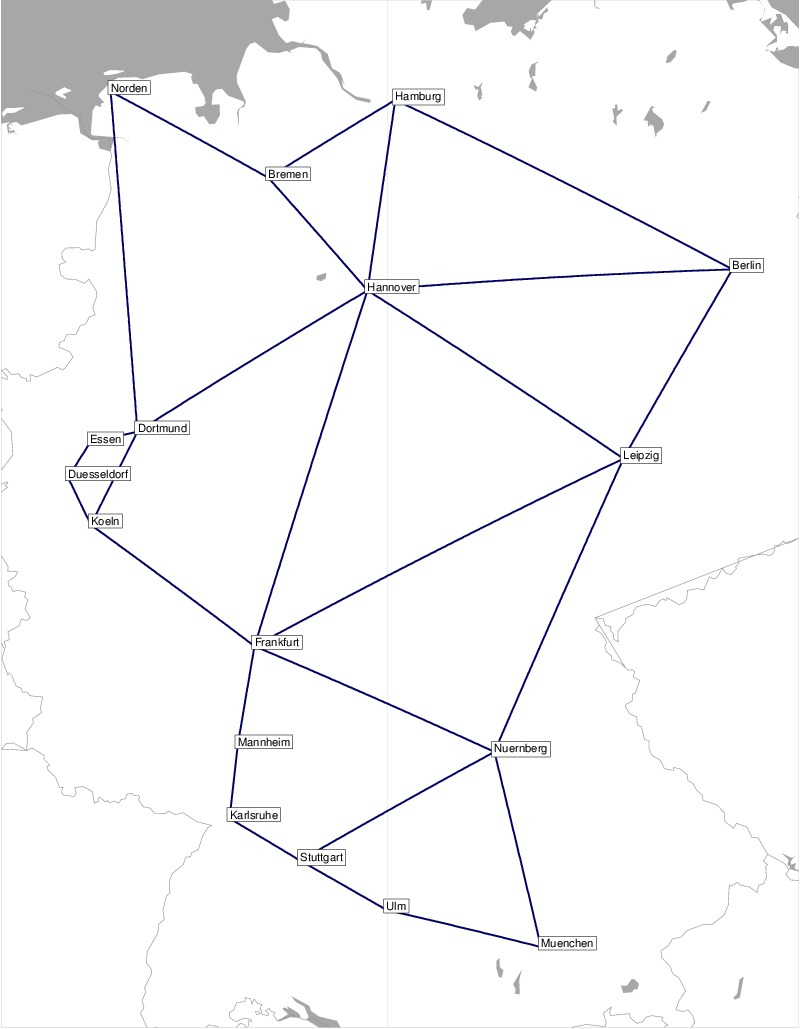

### Rozwiązanie modelem AMPL

In [ ]:
# podstawowy model do rozwiązywania zadań z sieciami typu full-mesh
sndlib_parser = SNDlib_Parser(SNDlib_Path+"nobel_germany_net.txt")
nodes, node_connections = sndlib_parser.get_nodes_edges_as_ints()

print(node_connections)

ampl_data_creator = AMPL_Data_Creator()
nobel_germany_dat = ampl_data_creator.generate_ampl_data(encrypted_bandwidth, regular_bandwidth, nodes, transponder_names, 1000, transponder_capacities, transponder_costs, node_connections)

AMPL_MODEL = "any-net.mod"
AMPL_DATA = "nobel_germany_net.dat"

with open(AMPL_PATH+AMPL_DATA, "w") as f:
  f.write(nobel_germany_dat)

In [ ]:
ampl_solve_other_task(nodes)

### Rozwiązanie algorytmem ewolucyjnym

In [ ]:
# reprezentację sieci tworzymy na podstawie jej opisu z serwisu sndlib
# zawartośc pliku tekstowego to format 'native' opisu sieci
sndlib_parser = SNDlib_Parser(SNDlib_Path+"atlanta_net.txt")
node_connections = sndlib_parser.get_nodes_edges_as_ints()[1]


In [ ]:
N = 15 # liczba węzłów w sieci fullmesh

mock_neigh_matrix = set_connections(N, node_connections)
mock_demand = torch.mul(torch.triu(torch.full((N, N), 44000, dtype=torch.float), diagonal=1), mock_neigh_matrix)


### Wizualizacja danych wejściowych

In [ ]:
visualize_input_data(
    mock_neigh_matrix,
    mock_demand,
    mock_transponder_costs,
    mock_transponder_capacities
)

### Wykonanie eksperymentu

In [ ]:
path_dist, trans_dist = get_opt_init_dist(N, T, encrypted_bandwidth, regular_bandwidth)
ea_config.path_edge_bandwidth_usage_init_distribution = path_dist
ea_config.path_transponder_assignment_init_distribution = trans_dist
ea_instance = ea_config
ea_instance.run(
    encrypted_bandwidth = encrypted_bandwidth,
    regular_bandwidth = regular_bandwidth,
    neigh_matrix=mock_neigh_matrix,
    demand=mock_demand,
    transponder_costs=mock_transponder_costs,
    transponder_capacities=mock_transponder_capacities
)

ea_summarize_run()